In [4]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import ast

import jax
import jax.numpy as jnp
from jax import Array

from nltk.stem import WordNetLemmatizer

from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
import seaborn as sns

from cartm import ContextTopicModel, AttentiveTopicModel
from cartm.preprocessing import (
    CorpusLoader,
    BatchedCorpusLoader,
    build_bow,
)
from cartm.metrics import (
    PerplexityMetric,
    NPMICoherenceMetric,
    SparsityMetric,
    TopicVarianceMetric,
)
from cartm.regularization import DecorrelationRegularization

sns.set_theme()

In [2]:
data = fetch_20newsgroups(data_home='./data/', subset='all').data

preprocessor = CorpusLoader(min_token_len=3, max_token_len=20, min_df=5, max_df=0.5)
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of tokens in preprocessed corpus: {len(document_bounds)}')

loader = BatchedCorpusLoader(
    data=tokenized_data,
    doc_bounds=document_bounds,
    batch_size=10000,
)
print(f'Number of batches: {len(loader)}')

vocab_size = len(preprocessor.vocabulary)
bow = build_bow(tokenized_data, document_bounds, vocab_size)

Total number of tokens in preprocessed corpus: 2722222
Number of batches: 273


In [6]:
td = TopicVarianceMetric(top_k=25, tag="TD@25")

decorr = DecorrelationRegularization(0.0, "wt")

model = AttentiveTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=100,
    n_topics=100,
    gamma=0.01,
    metrics=[td],
    regularizers=[decorr],
)

model.fit(
    loader,
    max_iter=50,
    verbose=2,
    seed=42,
)

Iteration [1/50], phi update diff norm: 1.1502
  Metrics:


TypeError: bincount requires ndarray or scalar arguments, got <class 'list'> at position 0.

### theta and context length

In [24]:
metrics_df = pd.read_csv('../context_experiments_results.csv', index_col=0)
metric_list = ["perplexity", "sparsity", "topic variance", "coherence"]
for metric_name in metric_list:
    metrics_df[metric_name] = metrics_df[metric_name].apply(ast.literal_eval)

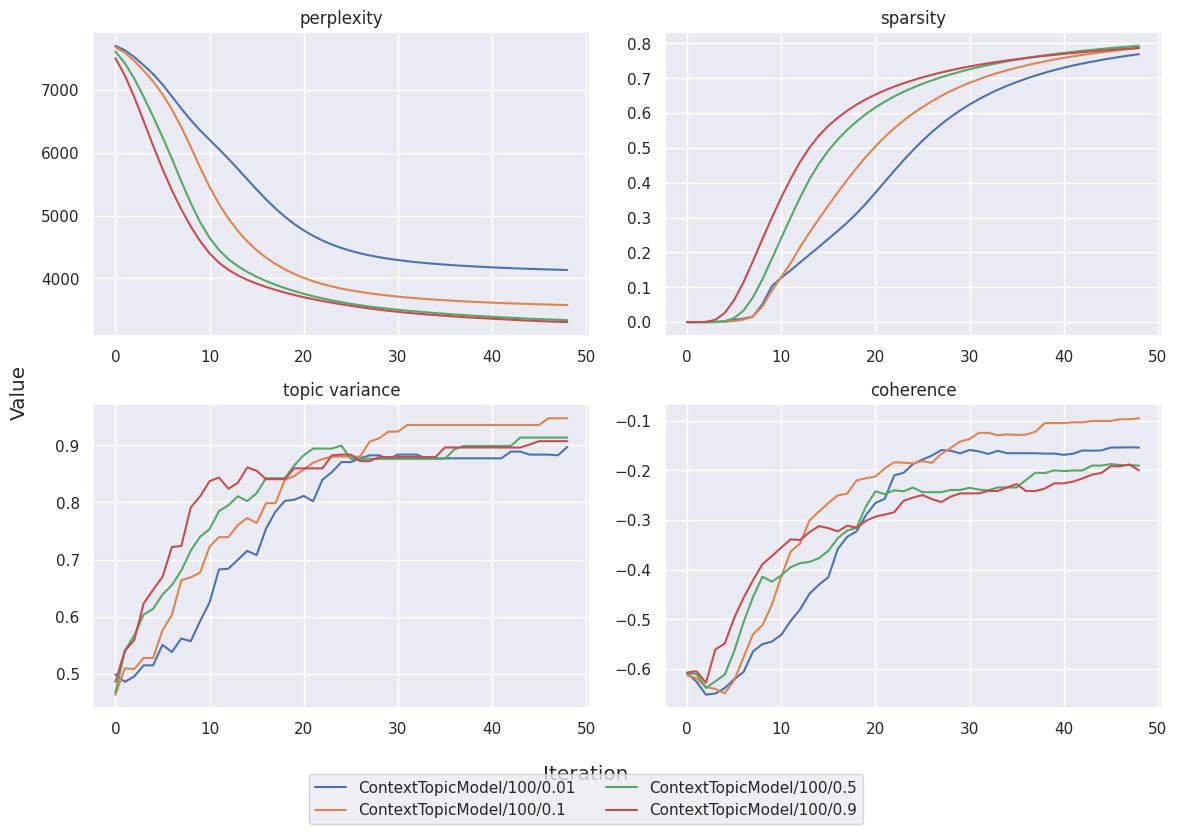

In [49]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

lines_labels = []
topics_mask = metrics_df.n_topics == 10
ctx_mask = metrics_df.ctx_len == 100
gamma_mask = metrics_df.gamma.isin([0.01, 0.1, 0.5, 0.9])
model_mask = metrics_df.model_type.isin(["ContextTopicModel"])
mask = topics_mask & ctx_mask & gamma_mask & model_mask
for row_id, row in metrics_df[mask].reset_index(drop=True).iterrows():
    for i, metric_name in enumerate(metric_list):
        label = f"{row["model_type"]}/{row["ctx_len"]}/{row["gamma"]}"
        metric = row[metric_name]
        line, = ax[i].plot(metric[1:], label=label)
        ax[i].set_title(metric_name)
        lines_labels.append((line, label))

unique_labels = {}
for line, label in lines_labels:
    if label not in unique_labels:
        unique_labels[label] = line

fig.supxlabel('Iteration')
fig.supylabel('Value')
fig.legend(
    unique_labels.values(),
    unique_labels.keys(),
    loc='lower center',
    ncol=len(unique_labels) // 2,
    bbox_to_anchor=(0.5, -0.05),
)
fig.tight_layout()
plt.show()

### Performance benchmark

In [134]:
benchmark_df = pd.read_csv('../benchmark_results.csv', index_col=0).drop('name', axis=1)
benchmark_df.head()

,compile_plus_run_sec,steady_mean_sec,steady_min_sec,steady_max_sec,steady_std,runs,model,ctx_len,n_topics,n_batches,batch_size,batched
0,16.737747,15.854412,15.689304,16.097093,0.139875,5,ContextTopicModel,100,100,324,10000,True
1,25.460459,25.225999,25.129216,25.495990,0.140454,5,AttentiveTopicModel,100,100,324,10000,True
2,10.017921,9.306385,9.226690,9.419959,0.077800,5,ContextTopicModel,100,100,33,100000,True
3,14.435014,14.295946,14.220650,14.372768,0.049990,5,AttentiveTopicModel,100,100,33,100000,True
4,14.535244,14.429397,14.293119,14.628475,0.143301,5,ContextTopicModel,50,100,324,10000,True


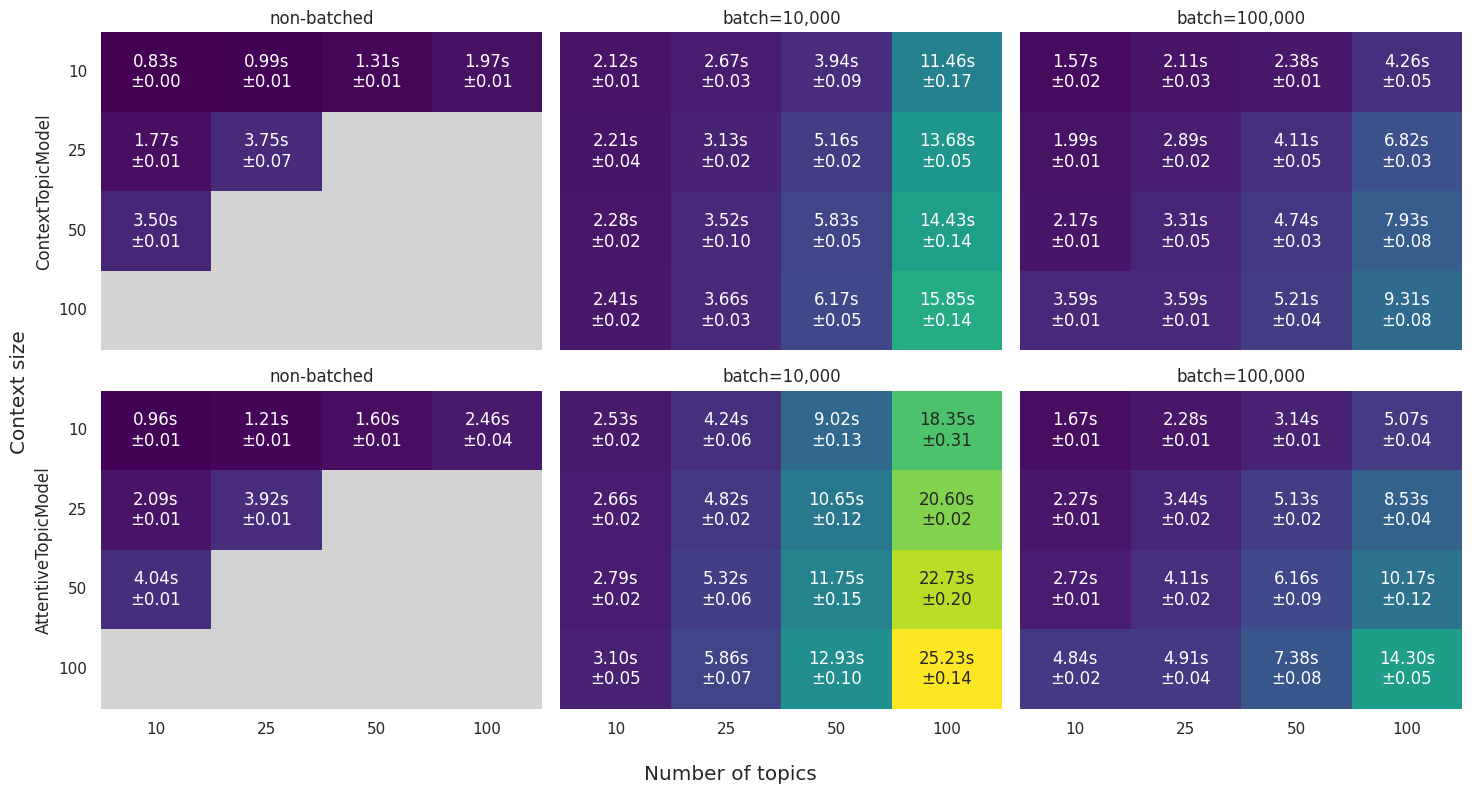

In [133]:
from matplotlib.cm import viridis


fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

vmin = benchmark_df["steady_mean_sec"].min()
vmax = benchmark_df["steady_mean_sec"].max()

cmap = viridis.copy()
cmap.set_bad(color="lightgray")

for i, model_type in enumerate(["ContextTopicModel", "AttentiveTopicModel"]):
    for j, batch_size in enumerate([None, 10_000, 100_000]):
        model_mask = benchmark_df.model == model_type
        if batch_size is None:
            batch_mask = (
                (benchmark_df.batched == False)
                & (benchmark_df.batch_size == 10_000)
            )
        else:
            batch_mask = (
                (benchmark_df.batch_size == batch_size)
                & benchmark_df.batched
            )
        records = benchmark_df[model_mask & batch_mask].copy()

        mean_pivot = records.pivot(
            index="ctx_len",
            columns="n_topics",
            values="steady_mean_sec",
        )
        std_pivot = records.pivot(
            index="ctx_len",
            columns="n_topics",
            values="steady_std",
        )
        if 100 not in mean_pivot.index:
            mean_pivot.loc[100] = [np.nan, np.nan, np.nan, np.nan]
            std_pivot.loc[100] = [np.nan, np.nan, np.nan, np.nan]

        def prepare_label(m, s):
            if np.isnan(m):
                return "NaN"
            return f"{m:.2f}s\n±{s:.2f}"

        labels = np.vectorize(prepare_label)(
            mean_pivot.values,
            std_pivot.reindex_like(mean_pivot).values
        )
        sns.heatmap(
            mean_pivot,
            mask=mean_pivot.isna(),
            cmap=cmap,
            annot=labels,
            fmt="",
            vmin=vmin,
            vmax=vmax,
            cbar=False,
            ax=ax[i][j],
        )

        batch_title = "non-batched" if batch_size is None else f"batch={batch_size:,}"
        ax[i][j].set_title(batch_title)
        ax[i][j].set_xlabel(None)

        if j == 0:
            ax[i][j].set_ylabel(model_type)
        else:
            ax[i][j].set_ylabel(None)
        ax[i][j].tick_params(axis="y", labelrotation=0)

fig.supxlabel("Number of topics")
fig.supylabel("Context size")
fig.tight_layout()
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv('../results/main_table/100topics/20ng/main_table_summary.csv').round(2)
df

,dataset,model,npmi_10_mean,npmi_10_std,topic_diversity_25_mean,topic_diversity_25_std,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,seed_mean,seed_std,train_time_sec_mean,train_time_sec_std
0,20ng,AttentiveTopicModel,0.27,0.01,0.73,0.01,0.61,0.01,0.59,0.01,1.0,1.0,1.89,0.47
1,20ng,AttentiveTopicModelNoNWT,0.25,0.00,0.62,0.01,0.61,0.00,0.59,0.00,1.0,1.0,1.35,0.14
2,20ng,BERTopic,0.30,0.01,0.74,0.01,0.50,0.02,0.49,0.02,1.0,1.0,7.32,4.86
3,20ng,ContextTopicModel,0.25,0.01,0.62,0.01,0.62,0.00,0.59,0.00,1.0,1.0,1.48,0.12
4,20ng,LDA,0.19,0.01,0.63,0.01,0.55,0.01,0.53,0.01,1.0,1.0,77.51,0.40
5,20ng,NMF,0.27,0.00,0.59,0.00,0.53,0.00,0.51,0.00,1.0,1.0,7.07,0.98
